# Seminar 8. Transformer, BERT, GPT

## Part 1. MT with Vanilla Transformer

Dataset link: https://www.kaggle.com/datasets/mohamedlotfy50/wmt-2014-english-german/data

In [ ]:
import numpy as np
import pandas as pd
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from tqdm import tqdm, trange

from torch.utils.data import Dataset, DataLoader


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)

BOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3


In [ ]:
chunks = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_train.csv', chunksize=3000, lineterminator='\n')
chunk_idx = random.sample(range(4_000_000//3000), 150)
print(f"First chunk: {min(chunk_idx)}, Last chunk: {max(chunk_idx)}")
df = pd.DataFrame()
for i, chunk in tqdm(enumerate(chunks), total=max(chunk_idx)):
    if i in chunk_idx:
        df = pd.concat([df, chunk.sample(1000, random_state=42)])
        if i == max(chunk_idx):
            break
df


First chunk: 20, Last chunk: 1332


  0%|          | 0/1332 [00:00<?, ?it/s]

,de,en
61801,"Die Zeiten sind in s, es wurden 512 MB (800000...",The times are in s for encrypting 512 MB (8000...
61190,Ich habe mein Angesicht nicht vor Beschämung u...,I hid not my face from b shame and spitting.
61817,Bucht die besten Hostels in Leh über Hostelsclub.,Book the best hostels in Leh with Hostelsclub.
60251,Diese hervorragende Zusammenarbeit sollte über...,This excellent way of cooperating should be ex...
62505,Die Stärke vieler afrikanischer Staaten kann n...,The strength of many African states can only b...
...,...,...
3996618,Es könnte auch mehr Kissen für unvorsichtige F...,"To the same level, in fact, as it did when all..."
3996406,Das Hotel ist ein Mitglied der Hotel- und Gast...,The hotel is a member of the Czech association...
3997157,"Als der Gallier sich sich verbanden, um ihr La...",When the Gallic ones were linked to defend the...
3997068,Cristinas Ehemann hat von diesem außergewöhnli...,"That exceptional spirit benefited her husband,..."


### EDA

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 61801 to 3997133
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   de      150000 non-null  object
 1   en      150000 non-null  object
dtypes: object(2)
memory usage: 3.4+ MB


In [ ]:
df.describe()


,de,en
count,150000,150000
unique,149064,148834
top,Die Aussprache ist geschlossen.,The debate is closed.
freq,119,133


In [ ]:
# df = df.drop_duplicates(subset=['de'])
# df = df.drop_duplicates(subset=['en'])
df = df.drop_duplicates()
df.shape


(149227, 2)

In [ ]:
df['symb_len_de'] = df['de'].apply(len)
df['symb_len_en'] = df['en'].apply(len)
df['word_len_de'] = df['de'].apply(lambda x: len(x.split(' ')))
df['word_len_en'] = df['en'].apply(lambda x: len(x.split(' ')))
df[['symb_len_de', 'symb_len_en', 'word_len_de', 'word_len_en']].describe()


/tmp/ipykernel_55/4230808515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['symb_len_de'] = df['de'].apply(len)
/tmp/ipykernel_55/4230808515.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['symb_len_en'] = df['en'].apply(len)
/tmp/ipykernel_55/4230808515.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

,symb_len_de,symb_len_en,word_len_de,word_len_en
count,149227.000000,149227.000000,149227.000000,149227.000000
mean,152.908884,138.997628,21.410113,23.126867
std,97.731237,110.998270,13.357774,17.036203
min,1.000000,1.000000,1.000000,1.000000
25%,87.000000,80.000000,12.000000,13.000000
50%,133.000000,121.000000,19.000000,20.000000
75%,195.000000,177.000000,27.000000,29.000000
max,9134.000000,20005.000000,1259.000000,2685.000000


/tmp/ipykernel_55/1938516181.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([df['symb_len_en'], df['symb_len_de']],
/tmp/ipykernel_55/1938516181.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df['word_len_en'], df['word_len_de']],


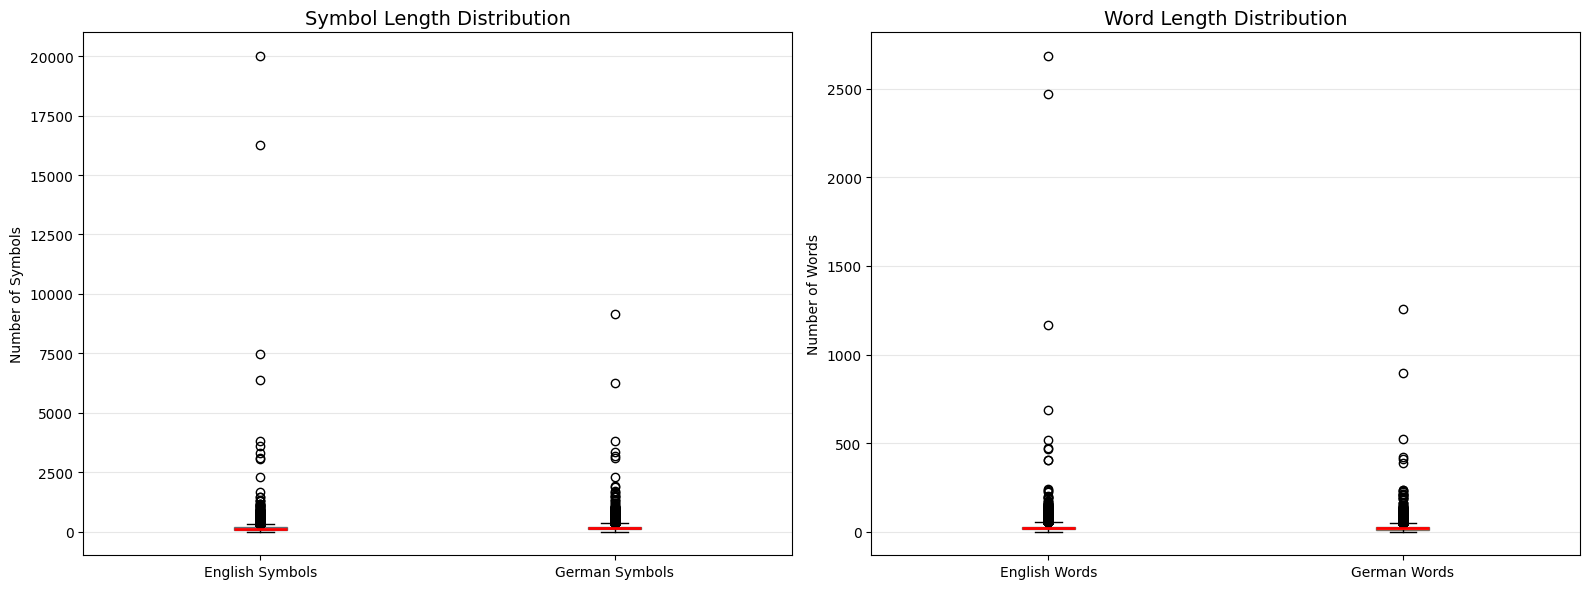

In [ ]:
import matplotlib.pyplot as plt

def plot_boxplots(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Boxplot for symbols
    ax1.boxplot([df['symb_len_en'], df['symb_len_de']], 
                labels=['English Symbols', 'German Symbols'],
                patch_artist=True, 
                boxprops=dict(facecolor='#1f77b4', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
    ax1.set_title('Symbol Length Distribution', fontsize=14)
    ax1.set_ylabel('Number of Symbols')
    ax1.grid(True, axis='y', alpha=0.3)

    # 2. Boxplot for words
    ax2.boxplot([df['word_len_en'], df['word_len_de']], 
                labels=['English Words', 'German Words'],
                patch_artist=True, 
                boxprops=dict(facecolor='#ff7f0e', alpha=0.5),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_title('Word Length Distribution', fontsize=14)
    ax2.set_ylabel('Number of Words')
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_boxplots(df)


In [ ]:
df_train = df.loc[df['word_len_en'] <= 25].reset_index(drop=True).copy()
df_train.shape


(98750, 6)

In [ ]:
df_train[['de', 'en']].sample(5, random_state=42).values


array([['(RO) In der Republik Moldau finden am 5. April Wahlen statt.',
        '(RO) Elections are taking place in the Republic of Moldova on 5 April.'],
       ['Weine: Vitovska IGT (2004-2005), Malvasia DOC (2004-2005), Kraška črnina/Rosso Carso DOC (2004-2005).',
        'Wines: Vitovska IGT 2004-2005, Malvazija DOC 2004-2005. Kraška črnina (Carso Red) Doc 2004-2005.'],
       ['Der Börsengang dieser Unternehmen – auch wenn es sich um etablierte Firmen handelt – liegt nicht länger als zehn Jahre zurück.',
        'The GEX includes German companies that are listed in the Prime Standard segment of FWB Frankfurter Wertpapierbörse, the Frankfurt Stock Exchange.'],
       ['Im Hinblick auf den Entlastungsbeschluss für den Rat möchte ich sagen, dass wir an den Bemerkungen und der Entscheidung des Ausschusses festhalten.',
        "With regard to the discharge decision where the Council is concerned, I should like to say that we stand by the committee's observations and decision."],
     

### Preprocessing

Examples demonstrate that there are problems with encoding. Additionally, we want to have punctuation as separate tokens, so let's preprocess our texts.

In [ ]:
import unicodedata


In [ ]:
def normalize_string(s):
    # Fix broken encoding, lowercase, strip
    s = unicodedata.normalize('NFC', s.lower().strip())
    # Fix found unrecognized symbol
    s = s.replace('\ufffd', 'ü') 
    # Separate punctuation marks
    s = re.sub(r"([\.!?,])", r" \1 ", s)
    # And remove any other symbols
    s = re.sub(r"[^a-zäöüß\.!?,]+", r" ", s)
    s = re.sub(r"\s+", r" ", s)
    return s.strip()


In [ ]:
df_train['de'] = df_train['de'].apply(normalize_string)
df_train['en'] = df_train['en'].apply(normalize_string)
df_train.head()


,de,en,symb_len_de,symb_len_en,word_len_de,word_len_en
0,"die zeiten sind in s , es wurden mb blöcke mit...",the times are in s for encrypting mb blocks of...,132,117,23,24
1,ich habe mein angesicht nicht vor beschämung u...,i hid not my face from b shame and spitting .,69,44,10,10
2,bucht die besten hostels in leh über hostelscl...,book the best hostels in leh with hostelsclub .,49,46,8,8
3,diese hervorragende zusammenarbeit sollte über...,this excellent way of cooperating should be ex...,96,81,12,13
4,"sukiyaki av , konventionen und anderen erwachs...","sukiyaki av , conventions and other adult site...",91,72,12,12


In [ ]:
df_train[['de', 'en']].sample(5, random_state=42).values


array([['ro in der republik moldau finden am . april wahlen statt .',
        'ro elections are taking place in the republic of moldova on april .'],
       ['weine vitovska igt , malvasia doc , kra ka rnina rosso carso doc .',
        'wines vitovska igt , malvazija doc . kra ka rnina carso red doc .'],
       ['der börsengang dieser unternehmen auch wenn es sich um etablierte firmen handelt liegt nicht länger als zehn jahre zurück .',
        'the gex includes german companies that are listed in the prime standard segment of fwb frankfurter wertpapierbörse , the frankfurt stock exchange .'],
       ['im hinblick auf den entlastungsbeschluss für den rat möchte ich sagen , dass wir an den bemerkungen und der entscheidung des ausschusses festhalten .',
        'with regard to the discharge decision where the council is concerned , i should like to say that we stand by the committee s observations and decision .'],
       ['wir besitzen mehr als terabytes für die speicherung von artikeln

### Vocab

In [ ]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "BOS", 1: "EOS", 2: "PAD", 3: "UNK"}
        self.n_words = 4  # Count system tokens

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

    def trim(self, min_count):
        keep_words = []
        for k, v in self.word2count.items():
            if v >= min_count:
                keep_words.append(k)

        print(f'keep_words {len(keep_words)} / {len(self.word2index)} = {len(keep_words) / len(self.word2index):.4f}')

        # Rebuild vocabs
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "BOS", 1: "EOS", 2: "PAD", 3: "UNK"}
        self.n_words = 4

        for word in keep_words:
            self.addWord(word)


In [ ]:
SOURCE_LANG = 'de'
TARGET_LANG = 'en'

source = Lang(SOURCE_LANG)
target = Lang(TARGET_LANG)

for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    source.addSentence(row['de'])
    target.addSentence(row['en'])

print(f"Source language vocab size: {source.n_words};\nTarget language vocab size: {target.n_words}")


  0%|          | 0/98750 [00:00<?, ?it/s]

Source language vocab size: 128332;
Target language vocab size: 64211


Vocabs are too big, let's throw out rare words

In [ ]:
source.trim(10)
target.trim(10)


keep_words 11608 / 128328 = 0.0905
keep_words 9269 / 64207 = 0.1444


### Test and Val data

Time to get our validation and test sets prepared.

In [ ]:
val_df = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_validation.csv')
test_df = pd.read_csv('/kaggle/input/wmt-2014-english-german/wmt14_translate_de-en_test.csv')


In [23]:
def clean_and_normalize(df_to_clean, df_train):
    # 1. Apply our normalization function
    df_to_clean['de'] = df_to_clean['de'].apply(normalize_string)
    df_to_clean['en'] = df_to_clean['en'].apply(normalize_string)
    # 2. Remove duplicates in subset
    df_to_clean = df_to_clean.drop_duplicates(subset=['de'])
    df_to_clean = df_to_clean.drop_duplicates(subset=['en'])
    # 3. Remove texts which are present in training set
    train_pairs = set(zip(df_train['de'], df_train['en']))
    mask = df_to_clean.apply(lambda row: (row['de'], row['en']) not in train_pairs, axis=1)
    df_to_clean = df_to_clean[mask]
    
    return df_to_clean
    

In [ ]:
val_df = clean_and_normalize(val_df, df_train)
test_df = clean_and_normalize(test_df, df_train)

print(f"Val size: {len(val_df)}, Test size: {len(test_df)}")


Val size: 2991, Test size: 3001


### Data set\loader

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, src_lang, trg_lang):
        self.data = dataframe
        self.src_lang = src_lang
        self.trg_lang = trg_lang

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # indexate everything (and add BOS with EOS)
        src_idxs = [0] + [self.src_lang.word2index.get(w, 3) for w in row['de'].split()] + [1]
        trg_idxs = [0] + [self.trg_lang.word2index.get(w, 3) for w in row['en'].split()] + [1]
        
        return torch.tensor(src_idxs, dtype=torch.long), torch.tensor(trg_idxs, dtype=torch.long)


In [ ]:
train_dataset = TranslationDataset(df_train, source, target)
val_dataset = TranslationDataset(val_df, source, target)
test_dataset = TranslationDataset(test_df, source, target)


In [ ]:
from torch.nn.utils.rnn import pad_sequence


In [28]:
def collate_fn(batch):
    src_batch, trg_batch = [], []
    for src_sample, trg_sample in batch:
        src_batch.append(src_sample)
        trg_batch.append(trg_sample)
    
    # padding_value=2 (PAD token)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=2)
    trg_batch = pad_sequence(trg_batch, batch_first=True, padding_value=2)
    
    return src_batch, trg_batch


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [ ]:
!pip install evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00


In [ ]:
import evaluate


2026-02-04 10:35:30.245136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770201330.398205      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770201330.441206      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770201330.797016      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770201330.797055      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770201330.797058      55 computation_placer.cc:177] computation placer alr

In [ ]:
import matplotlib.ticker as ticker


In [ ]:
def show_attention_map(input_sentence, output_words, attentions):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    input_tokens = normalize_string(input_sentence).split(' ') + ['EOS']
    
    ax.set_xticks(range(len(input_tokens)))
    ax.set_yticks(range(len(output_words)))
    
    ax.set_xticklabels(input_tokens, rotation=90, fontsize=12)
    ax.set_yticklabels(output_words, fontsize=12)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title("Attention Weights (DE -> EN)", pad=20, fontsize=14)
    plt.show()


### Transformer

In [ ]:
import math


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1)]


In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        # 1. Self-Attention
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        # 2. Feed Forward
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        # 3. Layer Norms (Add & Norm)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        # x -> Self-Attention -> Add & Norm
        attn_output, _ = self.self_attn(src, src, src, key_padding_mask=src_mask)
        src = self.norm1(src + self.dropout(attn_output))
        
        # x -> Feed Forward -> Add & Norm
        ff_output = self.feed_forward(src)
        src = self.norm2(src + self.dropout(ff_output))
        return src


In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        # 1. Masked Self-Attention
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        # 2. Cross-Attention
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask=None, trg_pad_mask=None, src_pad_mask=None):
        # 1. Masked Self-Attention
        attn_output, _ = self.self_attn(trg, trg, trg, attn_mask=trg_mask, key_padding_mask=trg_pad_mask)
        trg = self.norm1(trg + self.dropout(attn_output))
        
        # 2. Cross-Attention (Query from decoder, Key & Value from encoder)
        attn_output, weights = self.cross_attn(trg, enc_src, enc_src, key_padding_mask=src_pad_mask)
        trg = self.norm2(trg + self.dropout(attn_output))
        
        # 3. Feed Forward
        ff_output = self.feed_forward(trg)
        trg = self.norm3(trg + self.dropout(ff_output))
        return trg, weights


In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab, trg_vocab, d_model=512, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        self.src_emb = nn.Embedding(src_vocab, d_model)
        self.trg_emb = nn.Embedding(trg_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        
        self.encoder_blocks = nn.ModuleList([EncoderBlock(d_model, nhead, d_model*4, dropout) for _ in range(num_layers)])
        self.decoder_blocks = nn.ModuleList([DecoderBlock(d_model, nhead, d_model*4, dropout) for _ in range(num_layers)])
        
        self.fc_out = nn.Linear(d_model, trg_vocab)
        self.dropout = nn.Dropout(dropout)

    def make_trg_mask(self, trg):
        trg_len = trg.shape[1]
        mask = torch.triu(torch.ones((trg_len, trg_len), device=trg.device), diagonal=1).bool()
        return mask

    def forward(self, src, trg):
        # Padding masking
        src_pad_mask = (src == 2) # PAD=2
        trg_pad_mask = (trg == 2)
        trg_mask = self.make_trg_mask(trg)
        
        # Encoder
        enc_src = self.dropout(self.pos_enc(self.src_emb(src)))
        for block in self.encoder_blocks:
            enc_src = block(enc_src, src_pad_mask)
            
        # Decoder
        out = self.dropout(self.pos_enc(self.trg_emb(trg)))
        for block in self.decoder_blocks:
            out, attn_weights = block(out, enc_src, trg_mask, trg_pad_mask, src_pad_mask)
            
        return self.fc_out(out), attn_weights


In [ ]:
def train_transformer_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for src, trg in tqdm(loader, desc="Training Step"):
        src, trg = src.to(device), trg.to(device)
        
        # trg_input: [BOS, Word1, Word2] -> predict [Word1, Word2, EOS]
        trg_input = trg[:, :-1]
        trg_output = trg[:, 1:]
        
        optimizer.zero_grad()
        
        # Parallel forward pass
        output, _ = model(src, trg_input)
        
        # output: [batch, seq_len, vocab_size] -> [batch * seq_len, vocab_size]
        # trg_output: [batch, seq_len] -> [batch * seq_len]
        loss = criterion(output.reshape(-1, output.shape[-1]), trg_output.reshape(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)


In [ ]:
def evaluate_transformer_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for src, trg in tqdm(loader, desc="Validation Step"):
            src, trg = src.to(device), trg.to(device)
            
            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]
            
            output, _ = model(src, trg_input)
            loss = criterion(output.reshape(-1, output.shape[-1]), trg_output.reshape(-1))
            
            total_loss += loss.item()
            
    return total_loss / len(loader)


In [ ]:
D_MODEL = 512
N_HEAD = 8
NUM_LAYERS = 3
DROPOUT = 0.1
LR = 0.0001

transformer_model = Transformer(
    src_vocab=source.n_words, 
    trg_vocab=target.n_words, 
    d_model=D_MODEL, 
    nhead=N_HEAD, 
    num_layers=NUM_LAYERS, 
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=2) 
optimizer = torch.optim.Adam(transformer_model.parameters(), lr=LR)


Validation Step: 100%|██████████| 47/47 [00:02<00:00, 21.83it/s]


--> Saved best model with Val Loss: 4.6445
Epoch 1 | Train Loss: 4.9670 | Val Loss: 4.6445


Validation Step: 100%|██████████| 47/47 [00:02<00:00, 21.98it/s]


--> Saved best model with Val Loss: 4.3182
Epoch 2 | Train Loss: 4.2228 | Val Loss: 4.3182


Validation Step: 100%|██████████| 47/47 [00:02<00:00, 21.95it/s]


...

Epoch 8 | Train Loss: 2.8461 | Val Loss: 3.6501


Validation Step: 100%|██████████| 47/47 [00:02<00:00, 21.85it/s]


--> Saved best model with Val Loss: 3.6098
Epoch 9 | Train Loss: 2.7179 | Val Loss: 3.6098


Validation Step: 100%|██████████| 47/47 [00:02<00:00, 21.98it/s]


Epoch 10 | Train Loss: 2.6024 | Val Loss: 3.6183


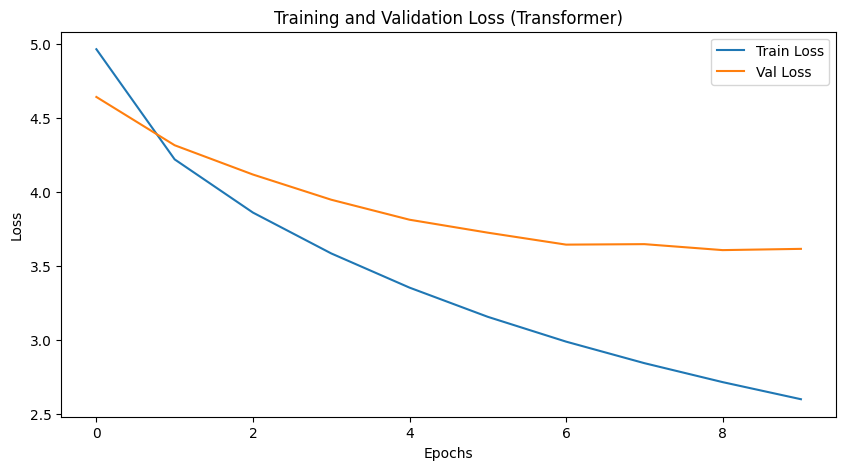

In [ ]:
train_losses_trans = []
val_losses_trans = []
best_val_loss = float('inf')

for epoch in range(1, 11):
    t_loss = train_transformer_epoch(transformer_model, train_loader, optimizer, criterion, device)
    v_loss = evaluate_transformer_epoch(transformer_model, val_loader, criterion, device)
    
    train_losses_trans.append(t_loss)
    val_losses_trans.append(v_loss)
    
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(transformer_model.state_dict(), 'best_transformer.pth')
        print(f"--> Saved best model with Val Loss: {v_loss:.4f}")

    print(f'Epoch {epoch} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}')

# Визуализация сравнения
plt.figure(figsize=(10, 5))
plt.plot(train_losses_trans, label='Train Loss')
plt.plot(val_losses_trans, label='Val Loss')
plt.title('Training and Validation Loss (Transformer)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
transformer_model.load_state_dict(torch.load('/kaggle/working/best_transformer.pth', weights_only=True))


<All keys matched successfully>

In [ ]:
def translate_transformer(model, sentence, source_lang, target_lang, device, max_len=50):
    all_attentions = []
    model.eval()
    
    # 1. Preprocess source
    normalized_src = normalize_string(sentence)
    src_tokens = [0] + [source_lang.word2index.get(w, 3) for w in normalized_src.split()] + [1]
    src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    # 2. Decoder starts with BOS
    trg_tokens = [0]
    
    # For attention visualization
    attentions = []

    with torch.no_grad():
        for i in range(max_len):
            trg_tensor = torch.tensor([trg_tokens], dtype=torch.long).to(device)
            
            # Forward pass
            # output: [1, cur_seq_len, vocab_size]
            # attn_weights: [1, cur_seq_len, src_len]
            output, attn_weights = model(src_tensor, trg_tensor)
            
            # Logits of the last predicted token
            next_token = output.argmax(2)[:, -1].item()
            all_attentions.append(attn_weights[:, -1, :].cpu())
            
            if next_token == 1: # EOS
                break
                
            trg_tokens.append(next_token)
            
    decoded_words = [target_lang.index2word[idx] for idx in trg_tokens[1:]] # Skip BOS
    attention_matrix = torch.cat(all_attentions, dim=0)
    
    return decoded_words, attention_matrix


In [ ]:
sent = 'Komm tanzen. Ich will nicht.'
translation, attn = translate_transformer(transformer_model, sent, source, target, device)
print(' '.join(translation))


UNK UNK . i do not want to be .


In [ ]:
sent = 'Ich bin ein Hund. Was mache?'
translation, attn = translate_transformer(transformer_model, sent, source, target, device)
print(' '.join(translation))


i am a dog what should be ?


In [ ]:
def get_transformer_bleu(df_test, model, source_lang, target_lang, device):
    bleu = evaluate.load('bleu')
    candidate_corpus = []
    references_corpus = []

    for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="BLEU Transformer"):
        src_sentence = row['de']
        trg_sentence = row['en']
        
        decoded_words, _ = translate_transformer(model, src_sentence, source_lang, target_lang, device)
        
        candidate_corpus.append(' '.join(decoded_words))
        references_corpus.append([trg_sentence])
        
    return bleu.compute(predictions=candidate_corpus, references=references_corpus)


In [ ]:
trans_bleu_results = get_transformer_bleu(test_df, transformer_model, source, target, device)
print(f"Transformer BLEU: {trans_bleu_results['bleu']*100:.2f}")


BLEU Transformer: 100%|██████████| 3001/3001 [05:08<00:00,  9.73it/s]


Transformer BLEU: 6.49


In [ ]:
trans_bleu_results


{'bleu': 0.06494219605845306,
 'precisions': [0.4030164466406077,
  0.12530496730750462,
  0.04660516222659894,
  0.017794380954486173],
 'brevity_penalty': 0.8072814610627302,
 'length_ratio': 0.823666985587802,
 'translation_length': 54236,
 'reference_length': 65847}

In [ ]:
def show_transformer_attention(sentence, model, source_lang, target_lang, device):
    decoded_words, attentions = translate_transformer(model, sentence, source_lang, target_lang, device)
    
    input_tokens = ['BOS'] + normalize_string(sentence).split() + ['EOS']
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    
    cax = ax.matshow(attentions.numpy(), cmap='viridis')
    fig.colorbar(cax)

    ax.set_xticks(range(len(input_tokens)))
    ax.set_yticks(range(len(decoded_words)))
    
    ax.set_xticklabels(input_tokens, rotation=90, fontsize=12)
    ax.set_yticklabels(decoded_words, fontsize=12)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.title("Transformer Cross-Attention (DE -> EN)", pad=20)
    plt.show()


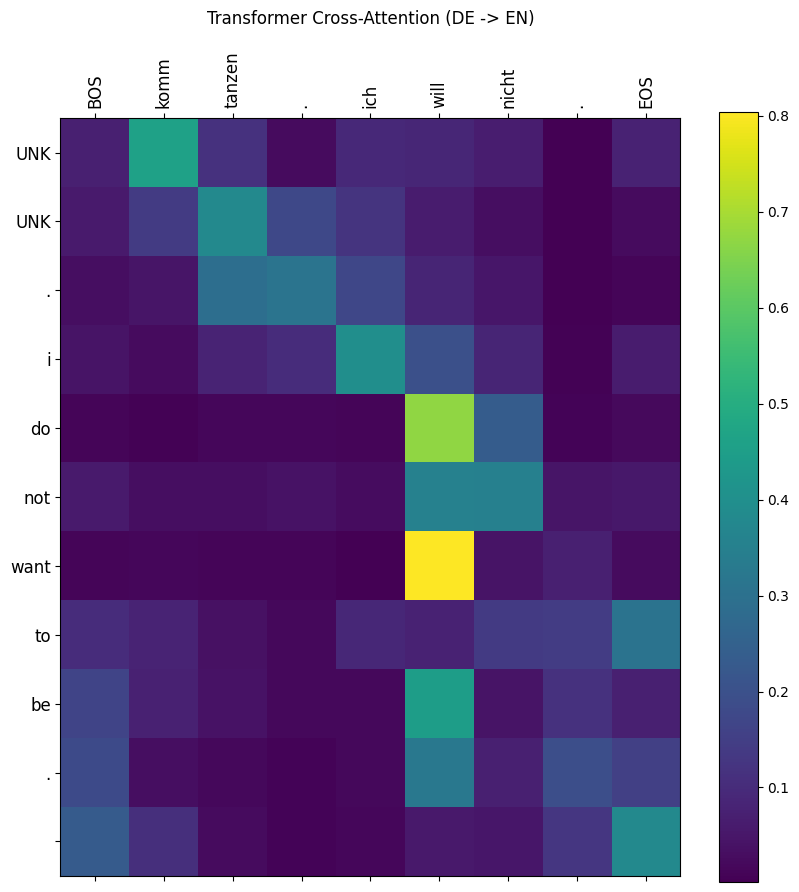

In [ ]:
show_transformer_attention(sent, transformer_model, source, target, device)


## Part 2. BERT

In [ ]:
!pip install evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


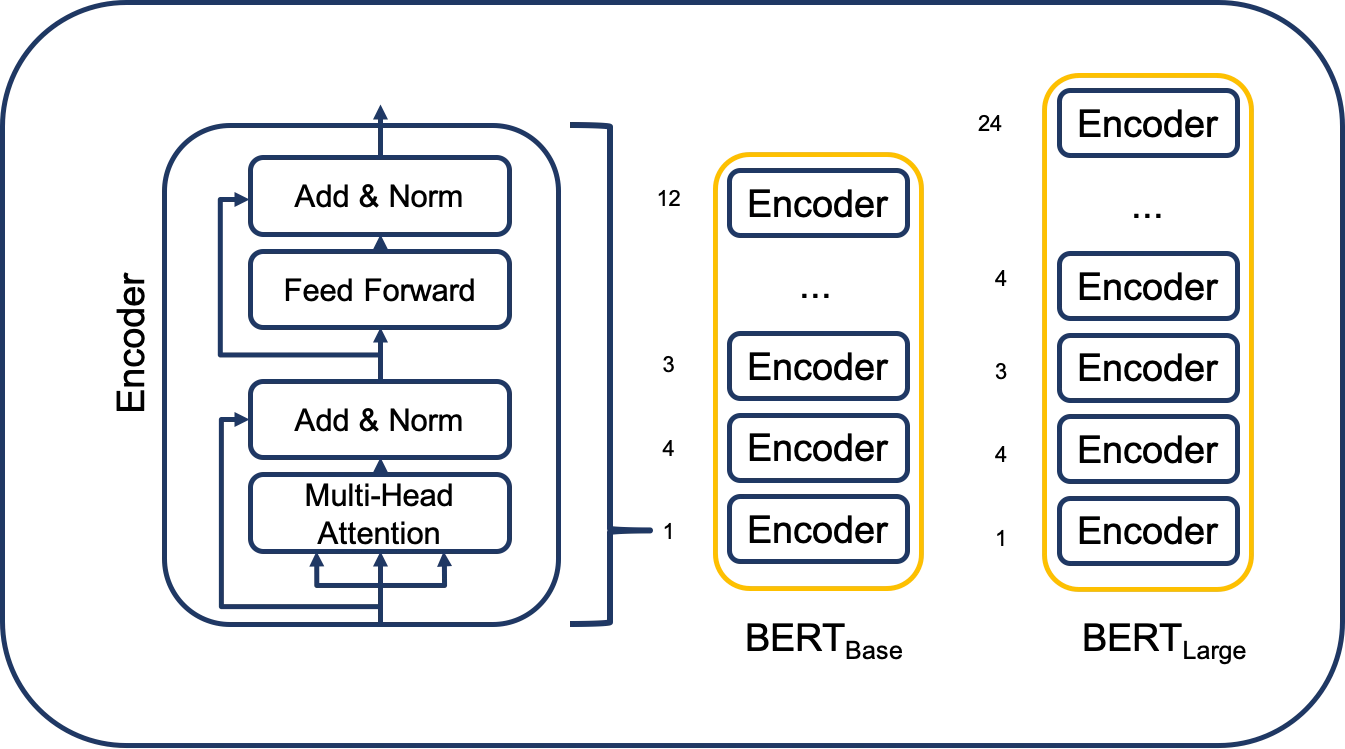

In [ ]:
import time
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
import evaluate
from peft import LoraConfig, get_peft_model
from sklearn.model_selection import train_test_split


2026-02-18 15:32:48.650022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771428768.831996      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771428768.885370      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771428769.319284      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771428769.319323      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771428769.319325      55 computation_placer.cc:177] computation placer alr

Dataset link: https://huggingface.co/datasets/Aniemore/cedr-m7

In [ ]:
data = load_dataset('Aniemore/cedr-m7')


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/746k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/186k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7528 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1882 [00:00<?, ? examples/s]

In [ ]:
data


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'source', 'label2ids'],
        num_rows: 7528
    })
    test: Dataset({
        features: ['text', 'labels', 'source', 'label2ids'],
        num_rows: 1882
    })
})

In [ ]:
train_ds = data['train'].to_pandas()
test_ds = data['test'].to_pandas()

train_ds


,text,labels,source,label2ids
0,Суровый гималайский медведь .,[neutral],lj,[0]
1,"Так, обнаружено несколько проблем с дисплеем (...",[neutral],lenta,[0]
2,У меня остается только один вопрос - является ...,[enthusiasm],lj,[3]
3,Забавно как люди в возрасте удивляются входящи...,[happiness],twitter,[1]
4,"Издание The Register отмечает, что у владельце...",[neutral],lenta,[0]
...,...,...,...,...
7523,Ухаха какая я злая!,[anger],twitter,[5]
7524,Я очень рада вас видеть.,[happiness],twitter,[1]
7525,Жизнь боль.,[sadness],twitter,[2]
7526,- Не удивительно .,[neutral],lj,[0]


In [ ]:
train_ds = train_ds[train_ds['labels'].str.len() == 1].reset_index(drop=True)
test_ds = test_ds[train_ds['labels'].str.len() == 1].reset_index(drop=True)

print(train_ds.shape, test_ds.shape)


(7437, 4) (1882, 4)


/tmp/ipykernel_55/624180296.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  test_ds = test_ds[train_ds['labels'].str.len() == 1].reset_index(drop=True)


In [ ]:
train_ds, val_ds = train_test_split(train_ds, test_size=0.15, random_state=42, stratify=train_ds['labels'])
val_ds


,text,labels,source,label2ids
2934,"Плакаты , зазывающие на марксистские собрания ...",[fear],lj,[4]
2343,"Согласно документу, россиянам, которые способс...",[neutral],lenta,[0]
3190,"«Это действительно нехорошо, потому что в этой...",[neutral],lenta,[0]
4998,Хочу новый в шараге... А по вам соскучилась(((,[sadness],twitter,[2]
1055,После казни блогеры с интересом рассматривают ...,[neutral],lenta,[0]
...,...,...,...,...
333,Около 20 человек пострадали в результате круше...,[sadness],lenta,[2]
924,"Но там видимо был кофе ... Впрочем , впоследст...",[neutral],lj,[0]
3675,"На нем видно, как странная «посетительница» не...",[neutral],lenta,[0]
5937,Ну хоть как то их надо распугивать из Москвы %)),[happiness],twitter,[1]


In [ ]:
train_ds['labels'].value_counts()


labels
[neutral]       2586
[happiness]     1282
[sadness]       1160
[enthusiasm]     483
[fear]           470
[anger]          326
[disgust]         14
Name: count, dtype: int64

In [ ]:
train_ds['label2ids'].value_counts()


label2ids
[0]    2586
[1]    1282
[2]    1160
[3]     483
[4]     470
[5]     326
[6]      14
Name: count, dtype: int64

In [ ]:
model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
train_hf = Dataset.from_pandas(train_ds)
val_hf = Dataset.from_pandas(val_ds)
test_hf = Dataset.from_pandas(test_ds)


In [ ]:
train_hf = train_hf.map(flatten_labels)
val_hf = val_hf.map(flatten_labels)
test_hf = test_hf.map(flatten_labels)

train_ds_tok = train_hf.map(tokenize_fn, batched=True)
val_ds_tok = val_hf.map(tokenize_fn, batched=True)
test_ds_tok = test_hf.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/6321 [00:00<?, ? examples/s]

Map:   0%|          | 0/1116 [00:00<?, ? examples/s]

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

Map:   0%|          | 0/6321 [00:00<?, ? examples/s]

Map:   0%|          | 0/1116 [00:00<?, ? examples/s]

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

In [ ]:
train_ds_tok


Dataset({
    features: ['text', 'labels', 'source', 'label2ids', '__index_level_0__', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6321
})

In [ ]:
train_ds_tok.to_pandas().head()


,text,labels,source,label2ids,__index_level_0__,label,input_ids,token_type_ids,attention_mask
0,потому что бегущие затягивают))меня пленил гла...,[happiness],twitter,[1],2468,1,"[2, 14665, 1046, 60759, 8057, 48903, 12729, 13...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,В том же Фидо это выражалось не только в сопро...,[neutral],lj,[0],2664,0,"[2, 282, 2079, 1712, 63698, 721, 2389, 75860, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"Я все выполнил , и потом долго вспоминал эту т...",[happiness],lj,[1],5625,1,"[2, 311, 2749, 40459, 16, 320, 12133, 27811, 3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,серый странный день :( поднимите мне настроение..,[sadness],twitter,[2],6855,2,"[2, 47937, 50953, 4045, 30, 12, 44140, 2205, 2...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
4,"тоже не выспался, но как ни странно, я бодро в...",[happiness],twitter,[1],5592,1,"[2, 19091, 769, 30906, 52952, 16, 1363, 1150, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [ ]:
cols_to_keep = ['input_ids', 'attention_mask', 'label']

train_ds_tok = train_ds_tok.remove_columns([c for c in train_ds_tok.column_names if c not in cols_to_keep])
val_ds_tok = val_ds_tok.remove_columns([c for c in val_ds_tok.column_names if c not in cols_to_keep])
test_ds_tok = test_ds_tok.remove_columns([c for c in test_ds_tok.column_names if c not in cols_to_keep])


In [ ]:
f1_metric = evaluate.load('f1')
accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    
    return {"accuracy": acc, "f1": f1}


In [ ]:
results_list = []


In [ ]:
def run_experiment(model_type, model_obj):
    print(f"Starting experiment: {model_type}")

    trainable_params = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
    all_params = sum(p.numel() for p in model_obj.parameters())

    lrs = {'Full FT': 5e-5, 'Transfer Learning': 1e-4, 'LoRA': 1e-3}

    training_args = TrainingArguments(
        output_dir=f"results_{model_type}",
        per_device_train_batch_size=64,
        eval_strategy="epoch",
        num_train_epochs=5,
        learning_rate=lrs.get(model_type, 5e-5),
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model_obj,
        args=training_args,
        train_dataset=train_ds_tok,
        eval_dataset=val_ds_tok,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )
    
    # Measure time
    start_time = time.time()
    trainer.train()
    end_time = time.time()
    
    # Evaluate
    eval_results = trainer.evaluate()
    
    # Append to global list
    results_list.append({
        "Method": model_type,
        "Trainable Params": f"{trainable_params:,}",
        "Trainable %": f"{(trainable_params / all_params) * 100:.2f}%",
        "Accuracy": round(eval_results["eval_accuracy"], 4),
        "Macro F1": round(eval_results["eval_f1"], 4),
        "Time (sec)": round(end_time - start_time, 2)
    })

    return trainer


In [ ]:
test_results = []


--- Scenario 0: Base Model ---

In [ ]:
model_base = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)

baseline_args = TrainingArguments(
    output_dir="temp_baseline",
    report_to="none",
    per_device_eval_batch_size=32,
    remove_unused_columns=False
)
baseline_trainer = Trainer(
    model=model_base,
    args=baseline_args,
    eval_dataset=test_ds_tok,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

baseline_results = baseline_trainer.evaluate()
test_results.append({
    "Method": "Baseline (Untrained)",
    "Test Accuracy": round(baseline_results["eval_accuracy"], 4),
    "Test Macro F1": round(baseline_results["eval_f1"], 4),
    "Trainable Params": "0"
})


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- Scenario 1: Full Fine-Tuning ---

In [ ]:
model_full = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)
trainer_full = run_experiment("Full FT", model_full)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting experiment: Full FT


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.957837,0.708781,0.334460
2,No log,0.769456,0.767921,0.494718
3,No log,0.716921,0.781362,0.534644
4,No log,0.695454,0.780466,0.533653
5,No log,0.695360,0.778674,0.546602


--- Scenario 2: Frozen (Transfer Learning) ---

In [ ]:
model_frozen = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)
for param in model_frozen.bert.parameters():
    param.requires_grad = False
trainer_tl = run_experiment("Transfer Learning", model_frozen)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting experiment: Transfer Learning


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.866926,0.466846,0.229649
2,No log,1.817102,0.519713,0.245252
3,No log,1.784614,0.541219,0.252368
4,No log,1.766136,0.543907,0.253695
5,No log,1.760082,0.544803,0.254491


--- Scenario 3: LoRA ---

In [ ]:
model_lora_raw = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)
lora_config = LoraConfig(
    r=16, lora_alpha=32, 
    target_modules=["query", "key", "value"], 
    lora_dropout=0.1, task_type="SEQ_CLS"
)
model_lora = get_peft_model(model_lora_raw, lora_config)
trainer_lora = run_experiment("LoRA", model_lora)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting experiment: LoRA


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.832046,0.736559,0.447188
2,No log,0.675294,0.780466,0.529568
3,No log,0.647101,0.780466,0.545820
4,No log,0.635842,0.789427,0.554498
5,No log,0.630225,0.787634,0.557843


In [ ]:
comparison_df = pd.DataFrame(results_list)

from IPython.display import display
print("\nFinal Comparison Table:")
display(comparison_df.sort_values(by="Macro F1", ascending=False))



Final Comparison Table:


,Method,Trainable Params,Trainable %,Accuracy,Macro F1,Time (sec)
2,LoRA,"92,047",0.31%,0.7876,0.5578,15.60
0,Full FT,"29,195,959",100.00%,0.7787,0.5466,16.12
1,Transfer Learning,"2,191",0.01%,0.5448,0.2545,9.55


In [ ]:
experiments = {
    "Full FT": trainer_full,
    "Frozen (TL)": trainer_tl,
    "LoRA": trainer_lora
}

for name, trainer in experiments.items():
    print(f"Final testing for: {name}")
    metrics = trainer.evaluate(test_ds_tok)

    trainable_params = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)

    test_results.append({
        "Method": name,
        "Test Accuracy": round(metrics["eval_accuracy"], 4),
        "Test Macro F1": round(metrics["eval_f1"], 4),
        "Trainable Params": f"{trainable_params:,}"
    })

df_results = pd.DataFrame(test_results)
display(df_results.sort_values("Test Macro F1", ascending=False))


Final testing for: Full FT
Final testing for: Frozen (TL)
Final testing for: LoRA


,Method,Test Accuracy,Test Macro F1,Trainable Params
1,Full FT,0.7800,0.5583,"29,195,959"
3,LoRA,0.7758,0.5544,"92,047"
2,Frozen (TL),0.5106,0.2475,"2,191"
0,Baseline (Untrained),0.1169,0.1037,0


In [ ]:
# Saving LoRA model
merged_model = model_lora.merge_and_unload()
merged_model.save_pretrained("bert_tuned_lora")


Additional sources:
1. BERT under the hood: https://neptune.ai/blog/how-to-code-bert-using-pytorch-tutorial
2. Low-level tuning of BERT: https://colab.research.google.com/drive/15_tOFLgf7E-4b-Y3UqoIvg-1Podp2vui?usp=sharing

## Part 3. GPT

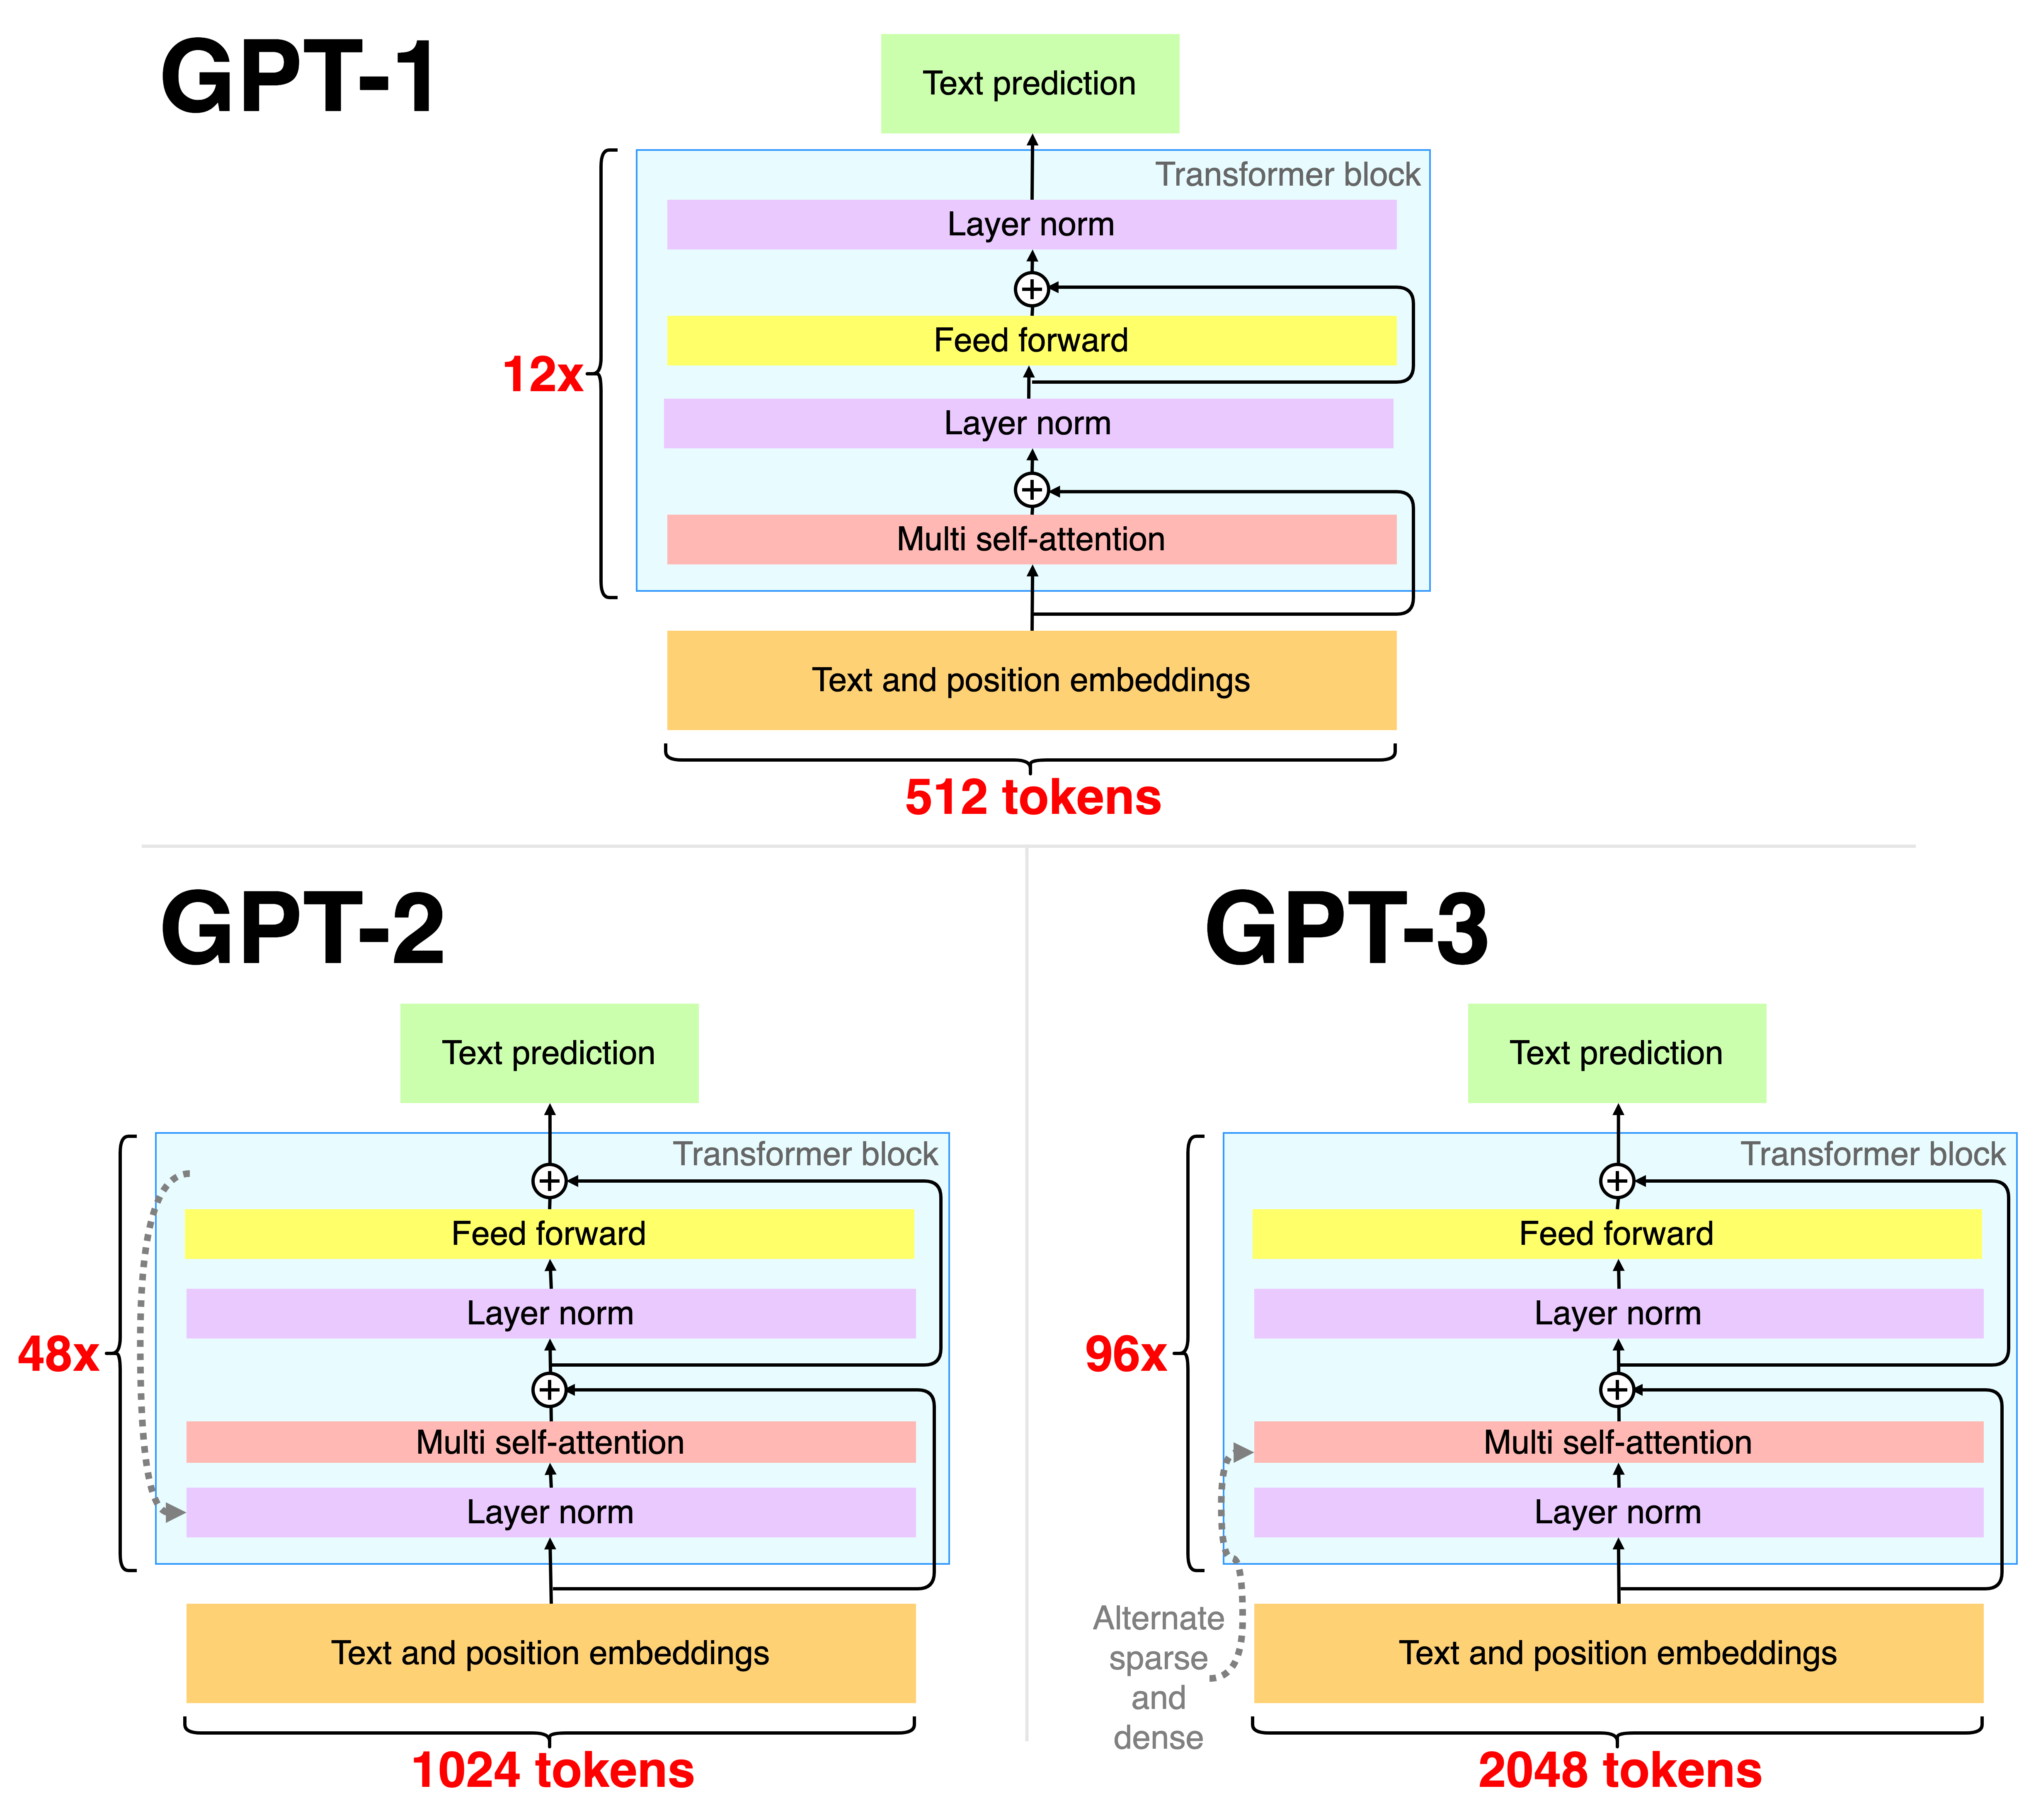

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
import re
from peft import LoraConfig, get_peft_model


Dataset link: https://www.kaggle.com/datasets/datadrivendecision/trump-tweets-2009-2025

In [ ]:
trump_df = pd.read_csv('/kaggle/input/datasets/datadrivendecision/trump-tweets-2009-2025/djt_posts_dec2025.csv')
trump_df


,id,date,platform,handle,text,favorite_count,repost_count,quote_flag,repost_flag,deleted_flag,word_count,hashtags,urls,user_mentions,media_count,media_urls,post_url,in_reply_to
0,115816402893182666,2025-12-31 21:54:21+00:00,Truth Social,realDonaldTrump,"Good News! George and Amal Clooney, two of the...",52,16,False,False,False,144,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
1,115816171466225987,2025-12-31 20:55:30+00:00,Truth Social,realDonaldTrump,We are removing the National Guard from Chicag...,44,16,False,False,False,107,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
2,115816098525451632,2025-12-31 20:36:57+00:00,Truth Social,realDonaldTrump,The Democrats are a bunch of cheaters and thie...,461,179,False,False,False,50,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
3,115816063544553030,2025-12-31 20:28:03+00:00,Truth Social,realDonaldTrump,Republicans: No more money to Fat Cat Insuranc...,309,97,False,False,False,24,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
4,115815971019162695,2025-12-31 20:04:31+00:00,Truth Social,realDonaldTrump,The United States has set a World Record on in...,36,11,False,False,False,76,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90338,1773561338,2009-05-12 14:07:28+00:00,Twitter,realDonaldTrump,"""My persona will never be that of a wallflower...",1904,1345,False,False,False,21,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1773561338,NaN
90339,1741160716,2009-05-08 20:40:15+00:00,Twitter,realDonaldTrump,New Blog Post: Celebrity Apprentice Finale and...,24,11,False,False,False,13,NaN,http://www.trumpuniversity.com/blog/post/2009/...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1741160716,NaN
90340,1737479987,2009-05-08 13:38:08+00:00,Twitter,realDonaldTrump,Donald Trump reads Top Ten Financial Tips on L...,33,15,False,False,False,17,NaN,https://www.youtube.com/watch?v=hmMkZD4VcNQ&fe...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1737479987,NaN
90341,1701461182,2009-05-05 01:00:10+00:00,Twitter,realDonaldTrump,Donald Trump will be appearing on The View tom...,259,34,False,False,False,22,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1701461182,NaN


In [ ]:
trump_df = trump_df.dropna(subset=['text'])
trump_df = trump_df.loc[(trump_df['text'] != '[Image]') & (trump_df['text'] != '[Video]') & (trump_df['text'] != '[QuickTime Video]')].reset_index()


In [ ]:
def clean(text):
    text = re.sub(r'^RT @\w+:?\s*', '', text) # remove retweets indicators
    text = re.sub(r'https?://\s*\S+', '', text) # remove links
    text = re.sub(r'www\.\s*\S+', '', text) # even broken ones
    text = re.sub(r'@\w+', '', text) # remove user tags
    text = text.replace('\xa0', ' ') # remove special whitespaces
    text = re.sub(r'\s+', ' ', text) # and redundant whitespaces
    text = re.sub(r"([^a-zA-Z0-9\s])", r" \1 ", text) # separate words and punctuation
    return text.lower().strip()


In [ ]:
trump_df['clean_text'] = trump_df['text'].apply(clean)
trump_df = trump_df[['text', 'clean_text']]
trump_df


,text,clean_text
0,"Good News! George and Amal Clooney, two of the...","good news ! george and amal clooney , two of..."
1,We are removing the National Guard from Chicag...,we are removing the national guard from chicag...
2,The Democrats are a bunch of cheaters and thie...,the democrats are a bunch of cheaters and thie...
3,Republicans: No more money to Fat Cat Insuranc...,republicans : no more money to fat cat insura...
4,The United States has set a World Record on in...,the united states has set a world record on in...
...,...,...
84824,"""My persona will never be that of a wallflower...",""" my persona will never be that of a wallflowe..."
84825,New Blog Post: Celebrity Apprentice Finale and...,new blog post : celebrity apprentice finale a...
84826,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...
84827,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...


In [ ]:
trump_ds = Dataset.from_pandas(trump_df[['clean_text']])


In [ ]:
model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer.pad_token = tokenizer.eos_token


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_fn(examples):
    return tokenizer(examples["clean_text"], truncation=True, max_length=128)

tokenized_dataset = trump_ds.map(tokenize_fn, batched=True, remove_columns=["clean_text"])
tokenized_dataset


Map:   0%|          | 0/84829 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 84829
})

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def generate_trump(prompt, temp=0.7):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        out = model.generate(
            **inputs, 
            max_length=60, 
            do_sample=True, 
            top_p=0.95, 
            temperature=temp,
            repetition_penalty=1.2,
            eos_token_id=tokenizer.eos_token_id
        )
    
    return tokenizer.decode(out[0], skip_special_tokens=True)

print(generate_trump("Make America"))
print(generate_trump("The fake news"))
print(generate_trump("Democrats are"))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Make America Great Again."


 (Photo: The Washington Post) Story Highlights Donald Trump's chief strategist, Paul Manafort, said he "cannot agree" with the news report on Russia ties. He also called it a 'fake' story by CNN and other media outlets that have repeatedly reported his


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The fake news media, which is the largest source of information on a daily basis about global problems and events across humanity – as well other people's lives in real time with their smartphones or through social networks via Facebook posts are increasingly being exposed to this world-renowned investigative journalism.

Democrats are looking for ways to improve their performance in the 2016 election.


In [ ]:
config = LoraConfig(
    r=16, 
    lora_alpha=32,
    target_modules=["c_attn"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)
model.print_trainable_parameters()


trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2174: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir="trump_gpt_lora",
    per_device_train_batch_size=16,
    num_train_epochs=1,
    learning_rate=3e-4,
    save_strategy="no",
    report_to="none",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

trainer.train()


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.432800
200,3.900700
300,3.807600
400,3.745500
500,3.672100
600,3.604600
700,3.638100
800,3.588700
900,3.562300
1000,3.565800


TrainOutput(global_step=5302, training_loss=3.4795224235805193, metrics={'train_runtime': 956.033, 'train_samples_per_second': 88.73, 'train_steps_per_second': 5.546, 'total_flos': 4636198244265984.0, 'train_loss': 3.4795224235805193, 'epoch': 1.0})

In [ ]:
print(generate_trump("Make America"))
print(generate_trump("The fake news"))
print(generate_trump("Democrats are"))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Make America great again !  pic . twitter / blqhvfk2t4 " london - trump - campaign _ news_ desk = 6080641763 , 0 x 1 \ nroberts < https:// wagenerdemocrats . com / uptimes


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The fake news media is trying to put the entire american economy back on track by using trump as an excuse .  they can't even get a handle !  donaldtrump will be president of usa for many years and this country has never been better ."  ... well , it ' s
Democrats are in a very important battle .  we need to do better !  and there is no more easy way than by winning ,   with the best of intentions but only one vote on your own side! nbcnews . com / politics / 2016 - 10 01 00 / pauls d


Additional sources:
1. Building your own GPT2: https://dev.to/amit_kharel_aae65abe2b111/heres-how-you-can-build-and-train-gpt-2-from-scratch-using-pytorch-345n?ysclid=mldot3k9cq738407453
2. Low-level tuning of GPT2: https://colab.research.google.com/drive/1EVyBlJ9usjoujI6ZcbeOcjcKjB1SNjk3?usp=sharing
3. Advanced generation techniques on GPT2: https://www.kaggle.com/code/tuckerarrants/text-generation-with-huggingface-gpt2/notebook